#   <font color='green'>PHYS 408H/MATH 426H Final Project</font> 
#### Cara Berman, Katelyn Whiteman, Ellie Gajewski, and Joss Ebersole



In [569]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

GOAL!!! Identify what shapes are best for flux calcuations

USE 3 different models of 3d shapes, oval/ellipsoid (bad), square/cube (bad), circle/sphere (good)

### <font color='DarkSeaGreen'>Part 1: Examining Circles & Spheres</font> 

In order to properly model a sphere, let's first make a model of a circle. 

In [570]:
# to create a circle, we can use the equation: x^2 + y^2 = r^2
# we can rearrange this equation to solve for y: y = sqrt(r^2 - x^2)

#try different values of r to see how the shape changes
#make sure to use positive values!
r = 4

def f(x):
    return np.sqrt(r**2 - x**2)

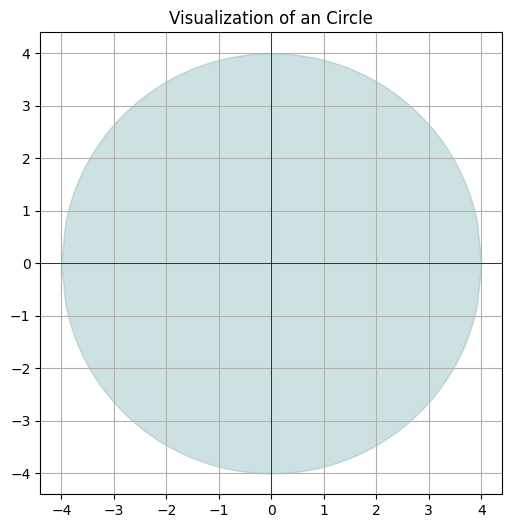

In [571]:
x = np.linspace(-r, r, 100)
upper_half = f(x)
lower_half = -f(x)

plt.figure(figsize=(8, 6))
plt.fill_between(x, lower_half, upper_half, color='CadetBlue', alpha=0.3)
plt.title("Visualization of an Circle")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')

In [572]:
#area calculations

def circle_area(r):
    return np.pi * r ** 2

print(f"The area of this circle is: {circle_area(r):.3f}")

The area of this circle is: 50.265


Great! Now that we have created a 2D visualization of a circle, we can extend this to 3D to create a sphere. 

In [573]:
# To create a sphere, we can use the equation x^2 + y^2 + z^2 = r^2. 
# We can rearrange this equation to solve for z: z = sqrt(r^2 - x^2 - y^2).

def g(x, y):
    return np.sqrt(r**2 - x**2 - y**2)


C:\Users\carab\AppData\Local\Temp\ipykernel_37840\2121355131.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  sphere.show()


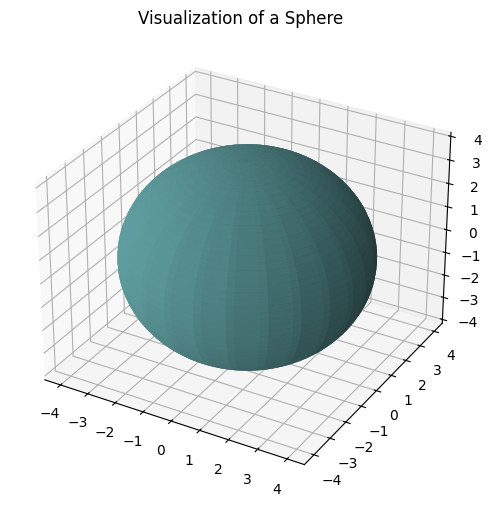

In [574]:
# Create a sphere using spherical coordinates
u = np.linspace(0, r * np.pi, 100)
v = np.linspace(0, np.pi, 100)

#use np.outer to create the mesh of the shape. 
x = r * np.outer(np.cos(u), np.sin(v))
y = r * np.outer(np.sin(u), np.sin(v))
z = r * np.outer(np.ones(np.size(u)), np.cos(v))

sphere = plt.figure(figsize=(8, 6))
ax = sphere.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color='CadetBlue', alpha=0.8)

ax.set_title("Visualization of a Sphere")
sphere.show()

In [575]:
#volume calculations

def sphere_vol(r): 
    return (4/3) * np.pi * r ** 3

print(f"The volume of this sphere is: {sphere_vol(r):.3f}")

The volume of this sphere is: 268.083


### Discussion Questions

* How many different ways could you symmetrically slice this sphere?
    * How does that relate to flux?

* Is a sphere a good representation of a 3d shape that could have electric flux?

### <font color='DarkSeaGreen'>Part 2: Examining Ovals & Ellipsoids</font> 

Now that we have examined the properties of spheres and their relation to flux, lets examine the properties of another similar shape. This time instead of a circle, we are going to look at an oval.

In [576]:
# to creat an oval, we can use the equation: (x^2/a^2) + (y^2/b^2) = 1
# we can rearrange this equation to solve for y: y = b*sqrt(1 - x^2/a^2)

#try different values of a and b to see how the shape changes
#make sure to use positive values!
a = 12
b = 5

#we will also need a c value for the 3d model. For this we will just use 1.

def g(x):
    return b*np.sqrt(1 - x**2/a**2)

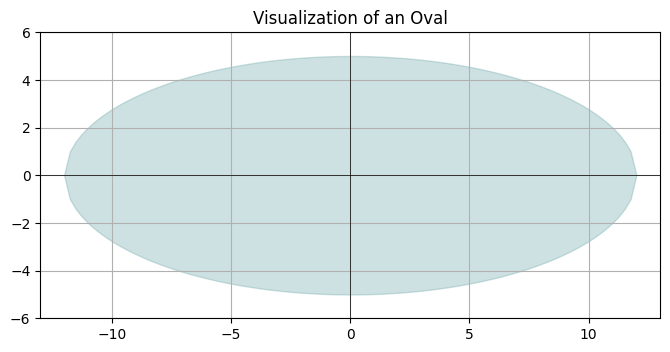

In [577]:
x = np.linspace(-a, a, 100)
upper_half = g(x)
lower_half = -g(x)

plt.figure(figsize=(8, 6))
plt.fill_between(x, lower_half, upper_half, color='CadetBlue', alpha=0.3)
plt.title("Visualization of an Oval")
plt.xlim(-a - 1, a + 1)
plt.ylim(-b - 1, b + 1)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')



Now let's turn this into a 3d model

In [578]:
#area of the oval

def oval_area(a,b):
    return np.pi * a * b

print(f"The area of this oval is: {oval_area(a, b):.2f}")

The area of this oval is: 188.50


C:\Users\carab\AppData\Local\Temp\ipykernel_37840\3320806992.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ellipsoid.show()


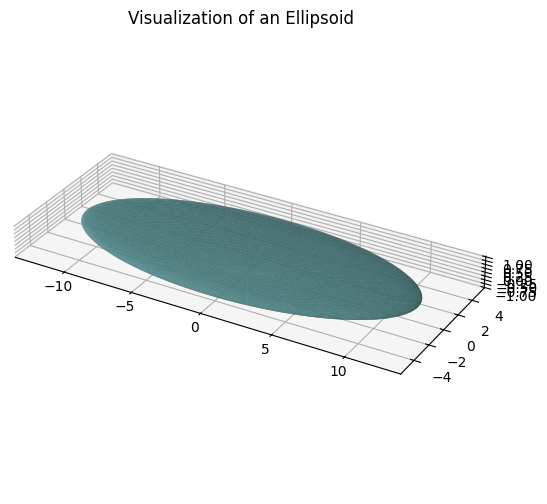

In [579]:
#Create an ellipsoid using 
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

x = a * np.outer(np.cos(u), np.sin(v))
y = b * np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

ellipsoid = plt.figure(figsize=(8, 6))
ax = ellipsoid.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color='CadetBlue', alpha=0.8)

ax.set_title("Visualization of an Ellipsoid")
ax.set_box_aspect([a, b, 1])
ellipsoid.show()

In [580]:
#calculate the area of the ellipsoid

def ellipsoid_volume(a,b,c):
    return (4/3) * np.pi * a * b * c

print(f"The area of this ellipsoid is: {ellipsoid_volume(a, b, 1):.2f}")

The area of this ellipsoid is: 251.33


### Discussion Questions

* How many different ways could you symmetrically slice this ellipsoid?
    * How does that relate to flux?

* Is an ellipsoid a good representation of a 3d shape that could have electric flux?

### <font color='DarkSeaGreen'>Part 3: Squares & Cubes</font>

Now lets look at something completely different, a cube. Because cubes are inherently more symmectrical than ellipsoids, it may make sense for them to have flux. Let's take a closer look

In [581]:
#lets make a square. In code this one is a little more tricky becuase squares can not be defined as functions. 
#In this case, let the top half and bottom half be represented as two different piecewise functions.

#np.where() acts as a conditional statement which checks if the x value falls within the given radius, ploting a horizantal line
#when we fill between the two horizantal lines it will create a square

def square_top(x, r=1):
    return np.where(np.abs(x) <= r, r, np.nan)

def square_bottom(x, r=1):
    return np.where(np.abs(x) <= r, -r, np.nan)

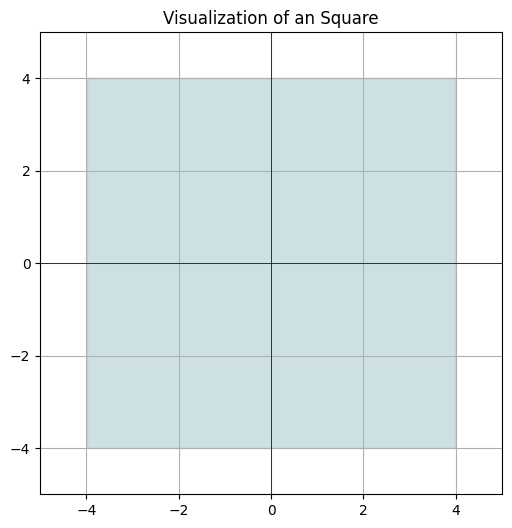

In [582]:
#try different values of R to see how the shape changes
#make sure to use positive values!
R = 4

x = np.linspace(-R-1, R+1, 100)

plt.figure(figsize=(8, 6))
plt.fill_between(x, square_bottom(x, r=R), square_top(x, r=R), color='CadetBlue', alpha=0.3)
plt.title("Visualization of an Square")
plt.xlim(-R-1, R+1)
plt.ylim(-R-1, R+1)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')

plt.show()



In [583]:
#area of the square

def square_area(r):
    return r ** 2

print(f"The area of this square is: {square_area(r):.3f}")

The area of this square is: 16.000


Now let's look at the model of a cube:

C:\Users\carab\AppData\Local\Temp\ipykernel_37840\3969333520.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  cube.show()


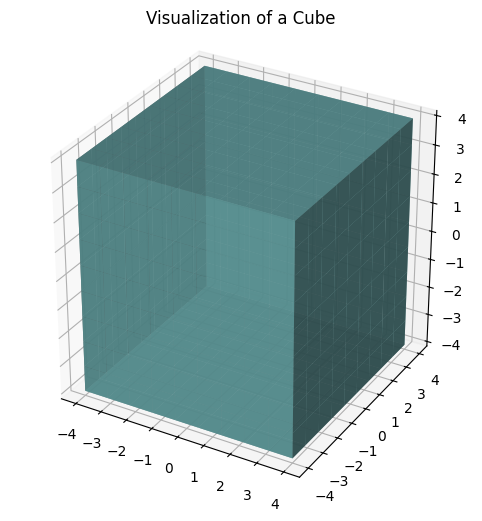

In [584]:
#now we will model this square as a cube
cube = plt.figure(figsize=(8,6))
ax = cube.add_subplot(111, projection="3d")

#create a grid for each face
arr = np.linspace(-R, R, 10)
X, Y = np.meshgrid(arr, arr)



#plot each surface
ax.plot_surface(X, Y, np.full_like(X, R), color='CadetBlue', alpha=0.8) #top
ax.plot_surface(X, Y, np.full_like(X, -R), color='CadetBlue', alpha=0.8) # bottom
ax.plot_surface(X, np.full_like(X, R), Y, color='CadetBlue', alpha=0.8) # front
ax.plot_surface(X, np.full_like(X, -R), Y, color='CadetBlue', alpha=0.8) # back
ax.plot_surface(np.full_like(X, R), X, Y, color='CadetBlue', alpha=0.8) # right
ax.plot_surface(np.full_like(X, -R), X, Y, color='CadetBlue', alpha=0.8) # left

ax.set_title("Visualization of a Cube")
ax.set_box_aspect([1, 1, 1])

cube.show()


In [585]:
#volume of the cube

def cube_volume(r):
    return r ** 3

print(f"The volume of this cube is: {cube_volume(r):.3f}")

The volume of this cube is: 64.000


### Discussion Questions

* How many different ways could you symmetrically slice this square?
    * How does that relate to flux?

* Is a cube a good representation of a 3d shape that could have electric flux?
    * What makes this shape different from the other two?